# 5 · Selectivity analysis

This notebook **reproduces the figures and tables of the selectivity results**
([`results/selectivity-assessments-results.md`](../results/selectivity-assessments-results.md),
methodology §7) from the committed summary tables. Each cell is labelled with the
figure/table it regenerates.

**Committed inputs**

| File | Used for |
|---|---|
| `070_CORRELATION/minimum_binding_energies.csv` | Tables 7–8, Figs 3–6, 9 |
| `070_CORRELATION/diffBE_CBD_relative.csv` | Table 11, Fig 10 |
| `070_CORRELATION/pharma_host_correlations.csv` | Table 9 |
| `070_CORRELATION/csq_sampling_summary.csv` | Table 10, Fig 8 |
| `040_DESCRIPTORS/guest_descriptors_3d.csv` | Tables 4–5, Figs 1, 5, 6, 8 |
| `040_DESCRIPTORS/guests_descriptors2.csv` | Fig 2 |
| `040_DESCRIPTORS/carboxylate_coordination.csv`, `hosts_descriptors.csv` | §8.1 Tables 2–3 |

> **What is *not* reproducible here.** Figure 7 (the per-configuration
> guest-to-cluster distance histogram) is computed from the raw SRD pools (HDF5),
> which are not committed; only its per-guest summary (Table 10 / Figure 8) is.
> Figures save to `figures/_companion/` (gitignored) so the polished committed
> figures in `figures/` are left untouched; set `FIG = Path("../figures")` below to
> regenerate them in place.

## Setup — load the committed tables

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, ".")
import pipeline_utils as pu
from pipeline_utils import TOPOLOGIES, FRAMEWORKS   # shp/csq/scu/sqc -> PCN-223/MOF-545/NU-902/PCN-225

THESIS = Path("../thesis"); CORR = THESIS / "070_CORRELATION"; DESC = THESIS / "040_DESCRIPTORS"
FIG = Path("../figures/_companion"); FIG.mkdir(parents=True, exist_ok=True)

HOST_COLORS = {"MOF-545": "#020035", "NU-902": "#f39c12", "PCN-223": "#0b7405", "PCN-225": "#029386"}
HOST_TO_TOPO = {mof: t for t, mof in FRAMEWORKS.items()}
TOPO_COLOR = {t: HOST_COLORS[FRAMEWORKS[t]] for t in TOPOLOGIES}
TOPO_LABEL = {t: f"{t}\n({FRAMEWORKS[t]})" for t in TOPOLOGIES}
FAM_COLOR = {"Pharmaceutical": "#378ADD", "Cannabinoid": "#1D9E75"}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

# Minimum binding energies, pivoted to guests (abbreviation) x topology.
be, be_table, gtype, gdesc = pu.load_results(CORR, DESC)
be_table = be_table.rename(columns=HOST_TO_TOPO).reindex(columns=TOPOLOGIES)
ph = [g for g in be_table.index if gtype.get(g) == "Pharmaceutical"]
cb = [g for g in be_table.index if gtype.get(g) == "Cannabinoid"]

# Supporting tables.
d3 = pd.read_csv(DESC / "guest_descriptors_3d.csv").set_index("Guest")
g2 = pd.read_csv(DESC / "guests_descriptors2.csv").set_index("Abbreviation")
samp = pd.read_csv(CORR / "csq_sampling_summary.csv")
corr9 = pd.read_csv(CORR / "pharma_host_correlations.csv")
diff = pd.read_csv(CORR / "diffBE_CBD_relative.csv").set_index("guest")
carbox = pd.read_csv(DESC / "carboxylate_coordination.csv")
hostd = pd.read_csv(DESC / "hosts_descriptors.csv", encoding="latin-1")
print(f"{len(ph)} pharmaceuticals, {len(cb)} cannabinoids with binding energies")

20 pharmaceuticals, 15 cannabinoids with binding energies


### Reproducing the derived correlation tables

The four derived tables in `070_CORRELATION/` are *not* primary data — they are
regenerated here from the committed minimum binding energies and guest descriptors,
so the notebook is self-contained: `ranking.csv` (per-guest topology ranking),
`diffBE_CBD_relative.csv` (cannabinoid BE referenced to CBD), `pharma_host_correlations.csv`
(per-host Pearson/Spearman of each descriptor vs minBE) and `spearman_pearson_coeff.csv`
(within-host Spearman summary per chemical class). The statistical definitions are
documented in [`energetic-data-analysis.md` §7](../energetic-data-analysis/energetic-data-analysis.md#71-correlation-with-structural-descriptors).

In [ ]:
# Regenerate 070_CORRELATION/*.csv from the committed primary data.
descdf = (g2.join(d3[["Rg", "NPR1", "NPR2", "min_rot_width"]], how="outer")
            [["NumHAcceptors", "NumHDonors", "MolLogP", "NumRotatableBonds",
              "NumAromaticRings", "MaxAbsPartialCharge", "Rg", "NPR1", "NPR2", "min_rot_width"]]
            .apply(pd.to_numeric, errors="coerce"))

# ranking.csv — topology ranking per guest (1 = strongest binding).
pu.topology_ranking(be_table).rename_axis("guest").to_csv(CORR / "ranking.csv")

# diffBE_CBD_relative.csv — cannabinoid BE referenced to CBD, per topology.
diff = pu.cbd_relative(be_table.loc[cb]).reindex(columns=TOPOLOGIES)
diff.rename_axis("guest").to_csv(CORR / "diffBE_CBD_relative.csv")

# pharma_host_correlations.csv — per-host Pearson/Spearman of descriptors vs minBE.
corr9 = pd.concat(
    [pu.descriptor_correlations(be_table.loc[ph, t].dropna(),
                                descdf.reindex(be_table.loc[ph, t].dropna().index))
       .reset_index(names="descriptor").assign(host=t)
     for t in TOPOLOGIES],
    ignore_index=True)[["host", "descriptor", "pearson_r", "pearson_p", "spearman_r", "spearman_p"]]
corr9.to_csv(CORR / "pharma_host_correlations.csv", index=False)

# spearman_pearson_coeff.csv — within-host Spearman summary, per chemical class.
def _summary(group, name):
    w = pu.within_host_correlations(be_table, descdf, group, TOPOLOGIES)
    rho = w[[c for c in w.columns if c.startswith("rho_")]]
    return pd.DataFrame({"set": name, "descriptor": w.index,
                         "mean_rho": rho.mean(axis=1).round(2).to_numpy(),
                         "sign_consistent": w["sign_consistent"].to_numpy(),
                         "n_sig_hosts": w["n_sig"].to_numpy()})
pd.concat([_summary(ph, "pharmaceutical"), _summary(cb, "cannabinoid")],
          ignore_index=True).to_csv(CORR / "spearman_pearson_coeff.csv", index=False)
print("regenerated ranking / diffBE_CBD_relative / pharma_host_correlations / spearman_pearson_coeff")

## 8. Structural characterization

### §8.1 — Host frameworks (Tables 2–3)
Table 1 (RCSR net invariants) is external; Table 2 is the direct cluster-coordination
analysis of the optimized structures, and Table 3 the Zeo++ pore descriptors.

In [2]:
print("Table 2 — carboxylate coordination per cluster:")
display(carbox)
print("\nTable 3 — Zeo++ pore descriptors:")
display(hostd[["MOF", "Df_A", "Di_A", "ASA_m2_g", "AV_cm3_g", "POAV_cm3_g"]].round(3))

Table 2 — carboxylate coordination per cluster:


,net,n_Zr_in_cell,n_clusters_in_cell,carboxylates_per_cluster,bridging_per_cluster,chelating_per_cluster,unclassified_per_cluster
0,csq,18,3.0,8.0,8.0,0.0,0.0
1,scu,6,1.0,8.0,8.0,0.0,0.0
2,shp,6,1.0,12.0,8.0,4.0,0.0
3,sqc,12,2.0,8.0,8.0,0.0,0.0



Table 3 — Zeo++ pore descriptors:


,MOF,Df_A,Di_A,ASA_m2_g,AV_cm3_g,POAV_cm3_g
0,MOF-545_dftb_geo-opt,30.342,31.618,3032.69,1.287,1.722
1,NU-902_dftb_geo-opt,11.680,13.550,3148.69,0.715,1.168
2,PCN-223_dftb_geo-opt,9.616,11.978,2755.48,0.397,0.833
3,PCN-225_dftb_geo-opt,6.721,10.800,3069.53,0.434,0.889


### §8.2 — Guest geometric & electronic characterization (Tables 4–5, Figures 1–2)

In [3]:
# Table 5 — shape classification from the principal-moment ratios NPR1/NPR2.
def shape_class(r):
    if r.NPR1 < 0.2 and r.NPR2 > 0.8: return "rod"
    if (r.NPR1 + r.NPR2) < 1.1 and r.NPR2 < 0.85: return "disc"
    return "intermediate"
d3["shape"] = d3.apply(shape_class, axis=1)
print("Table 5 — shape-class counts:", d3["shape"].value_counts().to_dict())
display(d3[["Rg", "NPR1", "NPR2", "min_rot_width", "long_axis_extent", "shape", "Family"]].round(2).head())

Table 5 — shape-class counts: {'intermediate': 21, 'rod': 12, 'disc': 4}


,Rg,NPR1,NPR2,min_rot_width,long_axis_extent,shape,Family
Guest,,,,,,,
AC,2.64,0.13,0.87,4.15,11.57,rod,Pharmaceutical
AT,4.62,0.07,0.99,6.24,17.56,rod,Pharmaceutical
BZA,3.53,0.45,0.68,6.80,13.36,intermediate,Pharmaceutical
CAR,2.80,0.45,0.78,6.29,11.56,intermediate,Pharmaceutical
CBC,4.15,0.36,0.86,8.90,14.88,intermediate,Cannabinoid


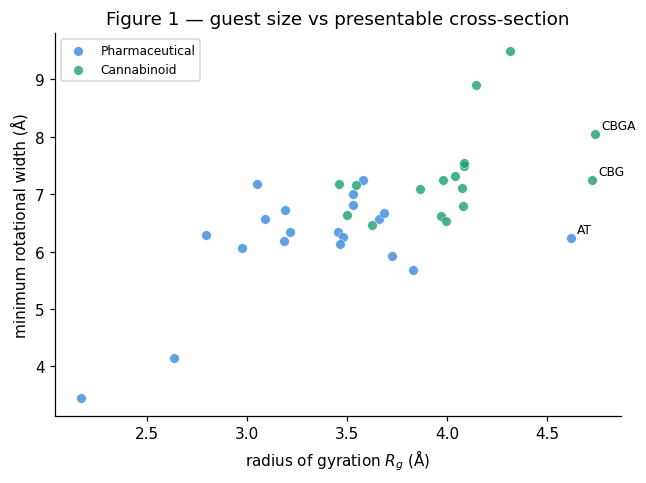

In [4]:
# Figure 1 — size (Rg) vs presentable cross-section (min rotational width).
fig, ax = plt.subplots(figsize=(6, 4.5))
for fam, col in FAM_COLOR.items():
    sub = d3[d3.Family == fam]
    ax.scatter(sub.Rg, sub.min_rot_width, s=40, color=col, alpha=0.8, edgecolors="white", lw=0.4, label=fam)
for g in ["AT", "CBGA", "CBG"]:
    if g in d3.index:
        ax.annotate(g, (d3.loc[g, "Rg"], d3.loc[g, "min_rot_width"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("radius of gyration $R_g$ (Å)"); ax.set_ylabel("minimum rotational width (Å)")
ax.set_title("Figure 1 — guest size vs presentable cross-section"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "guest_geometry_scatter.png", dpi=150, bbox_inches="tight"); plt.show()

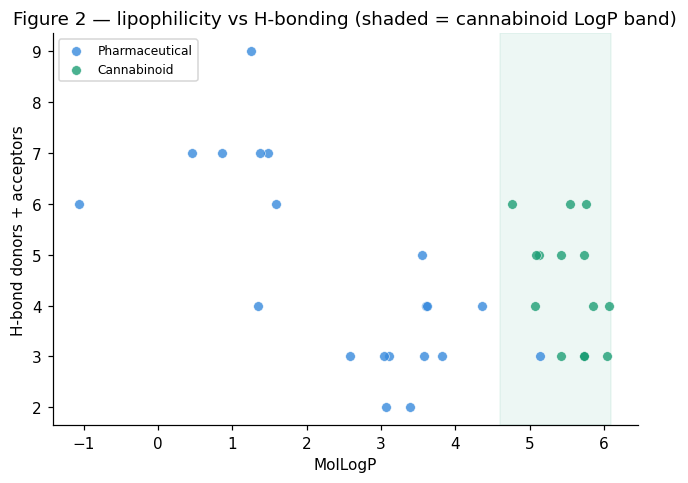

In [5]:
# Figure 2 — lipophilicity (MolLogP) vs H-bonding (donors + acceptors).
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.axvspan(4.6, 6.1, color="#1D9E75", alpha=0.08)
for fam, col in FAM_COLOR.items():
    abbrs = ph if fam == "Pharmaceutical" else cb
    x = g2.loc[abbrs, "MolLogP"]; y = g2.loc[abbrs, "NumHDonors"] + g2.loc[abbrs, "NumHAcceptors"]
    ax.scatter(x, y, s=40, color=col, alpha=0.8, edgecolors="white", lw=0.4, label=fam)
ax.set_xlabel("MolLogP"); ax.set_ylabel("H-bond donors + acceptors")
ax.set_title("Figure 2 — lipophilicity vs H-bonding (shaded = cannabinoid LogP band)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "guest_logp_hbond_scatter.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Minimum binding energies (Tables 7–8, Figure 3)

In [6]:
# Table 7 — per-host distribution.
t7 = pd.DataFrame([[FRAMEWORKS[t], t, int(be_table[t].notna().sum()),
                    round(be_table[t].mean(), 1), round(be_table[t].std(), 1),
                    round(be_table[t].min(), 1), round(be_table[t].max(), 1)] for t in TOPOLOGIES],
                  columns=["Host", "Topology", "N", "Mean", "Std", "Min", "Max"])
print("Table 7 — minimum binding energy distribution by host:"); display(t7)

# Table 8 — family means + two-sided Mann-Whitney U (the three trustworthy hosts).
print("Table 8 — family-level mean BE by host:")
t8 = []
for t in ["shp", "scu", "sqc"]:
    p = be_table.loc[ph, t].dropna(); c = be_table.loc[cb, t].dropna()
    t8.append([t, round(p.mean(), 1), round(c.mean(), 1), round(c.mean() - p.mean(), 1),
               round(stats.mannwhitneyu(p, c, alternative="two-sided").pvalue, 3)])
display(pd.DataFrame(t8, columns=["host", "pharma_mean", "canna_mean", "difference", "p_value"]))

Table 7 — minimum binding energy distribution by host:


,Host,Topology,N,Mean,Std,Min,Max
0,PCN-223,shp,35,-53.4,7.6,-69.4,-39.9
1,MOF-545,csq,31,-42.4,5.5,-52.2,-33.7
2,NU-902,scu,35,-59.5,12.7,-94.6,-34.4
3,PCN-225,sqc,35,-61.8,10.2,-96.7,-43.0


Table 8 — family-level mean BE by host:


,host,pharma_mean,canna_mean,difference,p_value
0,shp,-50.8,-56.9,-6.0,0.017
1,scu,-54.3,-66.3,-12.0,0.021
2,sqc,-57.5,-67.6,-10.1,0.004


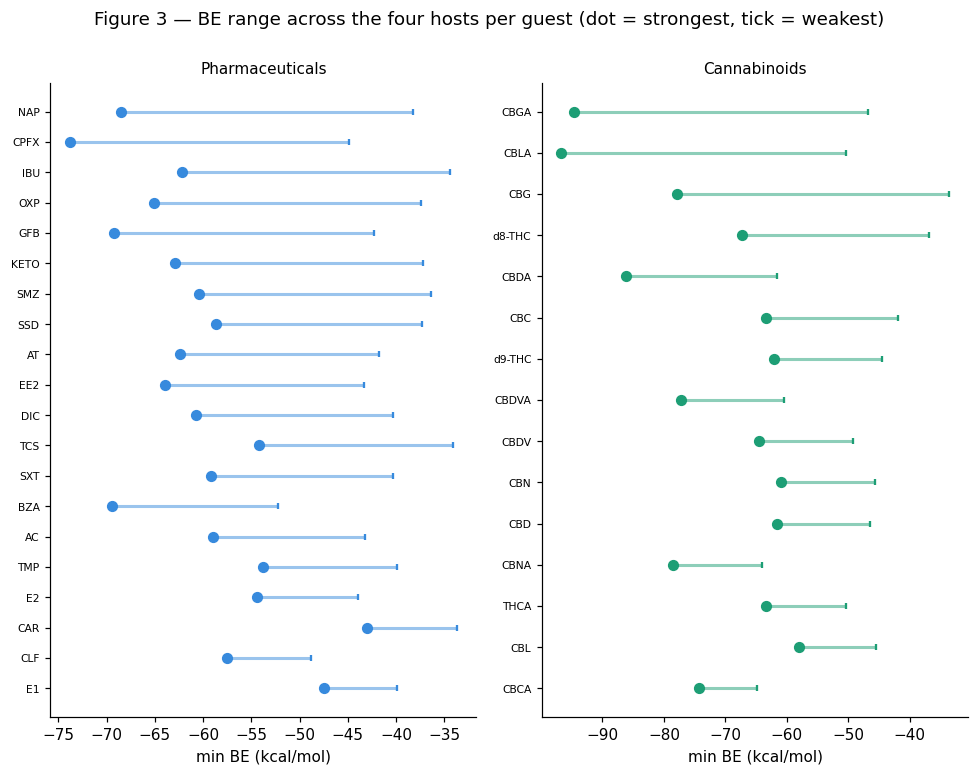

In [7]:
# Figure 3 — BE range across the four hosts, per guest.
def spread_panel(ax, abbrs, color, title):
    rng = (be_table.loc[abbrs].max(axis=1) - be_table.loc[abbrs].min(axis=1)).sort_values()
    for i, g in enumerate(rng.index):
        ax.hlines(i, be_table.loc[g].min(), be_table.loc[g].max(), color=color, alpha=0.5, lw=2)
        ax.scatter(be_table.loc[g].min(), i, color=color, s=40, zorder=3)
        ax.scatter(be_table.loc[g].max(), i, color=color, s=16, marker="|", zorder=3)
    ax.set_yticks(range(len(rng))); ax.set_yticklabels(rng.index, fontsize=7)
    ax.set_xlabel("min BE (kcal/mol)"); ax.set_title(title, fontsize=10)
fig, axes = plt.subplots(1, 2, figsize=(9, 7))
spread_panel(axes[0], ph, FAM_COLOR["Pharmaceutical"], "Pharmaceuticals")
spread_panel(axes[1], cb, FAM_COLOR["Cannabinoid"], "Cannabinoids")
fig.suptitle("Figure 3 — BE range across the four hosts per guest (dot = strongest, tick = weakest)", y=1.0)
fig.tight_layout(); fig.savefig(FIG / "BE_spread_pharma_canna.png", dpi=150, bbox_inches="tight"); plt.show()

## 10. Pharmaceutical selectivity (Figures 4–8, Tables 9–10)

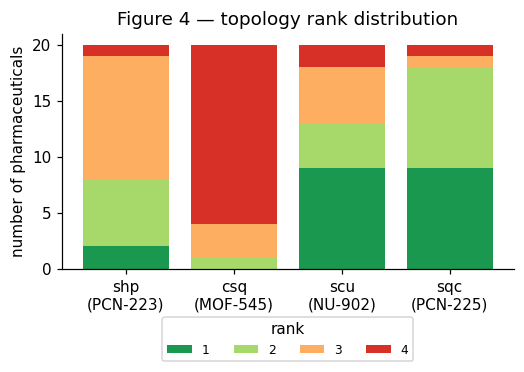

In [8]:
ranks = pu.topology_ranking(be_table.loc[ph])   # rank 1..4 per pharmaceutical

# Figure 4 — topology rank distribution.
fig, ax = plt.subplots(figsize=(5, 3.6))
rank_cols = {1: "#1a9850", 2: "#a6d96a", 3: "#fdae61", 4: "#d73027"}
bottom = np.zeros(len(TOPOLOGIES))
for r in [1, 2, 3, 4]:
    counts = [int((ranks[t] == r).sum()) for t in TOPOLOGIES]
    ax.bar([TOPO_LABEL[t] for t in TOPOLOGIES], counts, bottom=bottom, color=rank_cols[r], label=str(r))
    bottom += counts
ax.set_ylabel("number of pharmaceuticals"); ax.set_title("Figure 4 — topology rank distribution")
ax.legend(title="rank", fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout(); fig.savefig(FIG / "topology_preference.png", dpi=150, bbox_inches="tight"); plt.show()

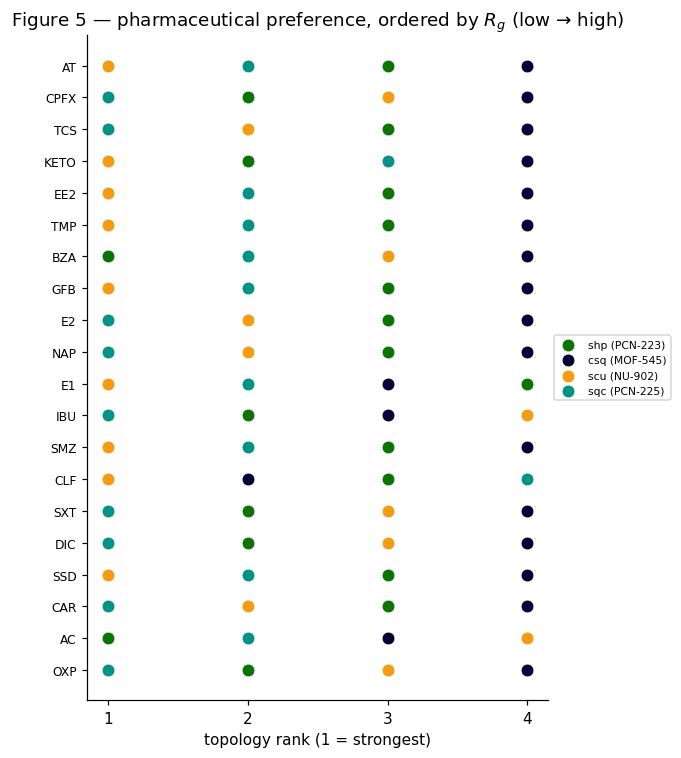

In [9]:
# Figure 5 — pharmaceutical ranks, ordered by Rg (low at bottom, high at top).
order = d3.loc[ph, "Rg"].sort_values(ascending=True).index
fig, ax = plt.subplots(figsize=(6, 7))
for t in TOPOLOGIES:
    ax.scatter(ranks.loc[order, t], range(len(order)), s=70, color=TOPO_COLOR[t],
               label=f"{t} ({FRAMEWORKS[t]})", edgecolors="white", lw=0.5, zorder=3)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xticks([1, 2, 3, 4]); ax.set_xlabel("topology rank (1 = strongest)")
ax.set_title("Figure 5 — pharmaceutical preference, ordered by $R_g$ (low → high)")
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout(); fig.savefig(FIG / "pharma_rank_by_Rg.png", dpi=150, bbox_inches="tight"); plt.show()

In [10]:
# Table 9 — full per-host correlation table (committed).
print("Table 9 — pharmaceutical guest descriptor vs minBE correlations, by host:")
nsig = ((corr9.pearson_p < 0.05) | (corr9.spearman_p < 0.05)).sum()
print(f"nominally significant rows: {nsig} of {len(corr9)} (none survive Bonferroni)")
display(corr9.round(3))

Table 9 — pharmaceutical guest descriptor vs minBE correlations, by host:
nominally significant rows: 3 of 40 (none survive Bonferroni)


,host,descriptor,pearson_r,pearson_p,spearman_r,spearman_p
0,shp,NumHAcceptors,-0.220,0.351,-0.406,0.076
1,shp,NumHDonors,-0.375,0.103,-0.375,0.103
2,shp,MolLogP,0.338,0.145,0.433,0.056
3,shp,NumAromaticRings,-0.313,0.179,-0.283,0.226
4,shp,NumRotatableBonds,-0.385,0.094,-0.298,0.202
5,shp,MaxAbsPartialCharge,0.044,0.854,0.183,0.440
6,shp,Rg,0.021,0.930,-0.026,0.915
7,shp,min_rot_width,0.333,0.152,0.337,0.146
8,shp,NPR1,-0.140,0.556,-0.026,0.915
9,shp,NPR2,0.427,0.061,0.223,0.346


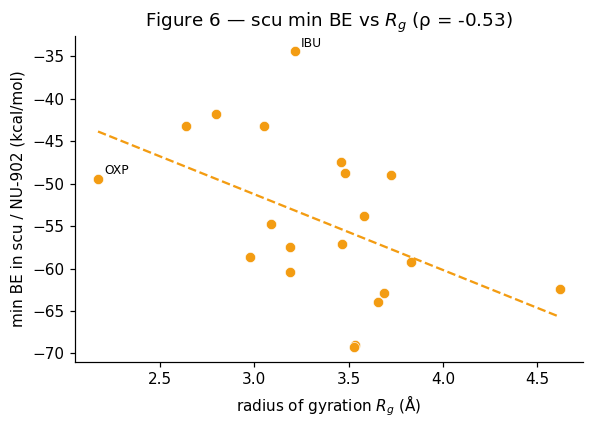

In [11]:
# Figure 6 — the one host/descriptor pair reaching p < 0.02: scu minBE vs Rg.
x = d3.loc[ph, "Rg"]; y = be_table.loc[ph, "scu"]; m = x.notna() & y.notna()
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(x, y, s=45, color=TOPO_COLOR["scu"], edgecolors="white", lw=0.4)
b1, b0 = np.polyfit(x[m], y[m], 1); xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, b1 * xs + b0, "--", color=TOPO_COLOR["scu"], lw=1.5)
for g in ["IBU", "OXP"]:
    ax.annotate(g, (d3.loc[g, "Rg"], be_table.loc[g, "scu"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("radius of gyration $R_g$ (Å)"); ax.set_ylabel("min BE in scu / NU-902 (kcal/mol)")
ax.set_title(f"Figure 6 — scu min BE vs $R_g$ (ρ = {stats.spearmanr(x[m], y[m])[0]:.2f})")
fig.tight_layout(); fig.savefig(FIG / "scu_minBE_vs_Rg.png", dpi=150, bbox_inches="tight"); plt.show()

### csq sampling-volume bias (Table 10, Figure 8)
Figure 7 (the per-configuration distance histogram) needs the raw SRD pools and is
not reproduced here; its per-guest summary is below.

Table 10 — % of SRD configurations within 7 Å of a cluster, in csq:


,abbrev,Rg,mean_dist,pct_within_7A
0,OXP,2.172,10.417,6.295
1,AC,2.636,10.614,4.760
2,CLF,3.189,10.826,3.440
3,NAP,3.465,10.992,2.840
4,TCS,3.725,10.992,2.590
5,AT,4.621,11.383,2.455
6,SSD,2.975,10.984,2.430
7,IBU,3.215,11.042,2.375
8,KETO,3.686,11.077,2.185
9,SXT,3.090,10.994,2.150


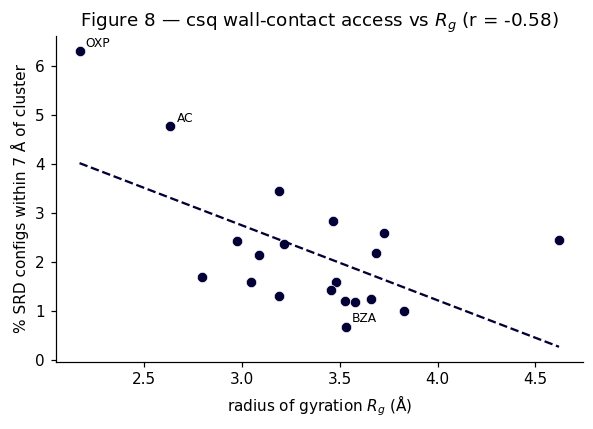

In [12]:
s = samp.dropna(subset=["Rg", "pct_within_7A"]).sort_values("pct_within_7A", ascending=False)
print("Table 10 — % of SRD configurations within 7 Å of a cluster, in csq:")
display(s[["abbrev", "Rg", "mean_dist", "pct_within_7A"]].round(3).reset_index(drop=True))

# Figure 8 — wall-contact access vs Rg.
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(s.Rg, s.pct_within_7A, s=45, color=HOST_COLORS["MOF-545"], edgecolors="white", lw=0.4)
b1, b0 = np.polyfit(s.Rg, s.pct_within_7A, 1); xs = np.linspace(s.Rg.min(), s.Rg.max(), 50)
ax.plot(xs, b1 * xs + b0, "--", color=HOST_COLORS["MOF-545"], lw=1.5)
for _, r in s.iterrows():
    if r.abbrev in ("OXP", "AC", "BZA"):
        ax.annotate(r.abbrev, (r.Rg, r.pct_within_7A), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("radius of gyration $R_g$ (Å)"); ax.set_ylabel("% SRD configs within 7 Å of cluster")
ax.set_title(f"Figure 8 — csq wall-contact access vs $R_g$ (r = {stats.pearsonr(s.Rg, s.pct_within_7A)[0]:.2f})")
fig.tight_layout(); fig.savefig(FIG / "csq_wallcontact_vs_Rg.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Cannabinoid selectivity (Figures 9–10, Table 11)

cannabinoid std per host: {'shp': 5.8, 'csq': 5.7, 'scu': 13.4, 'sqc': 10.1}


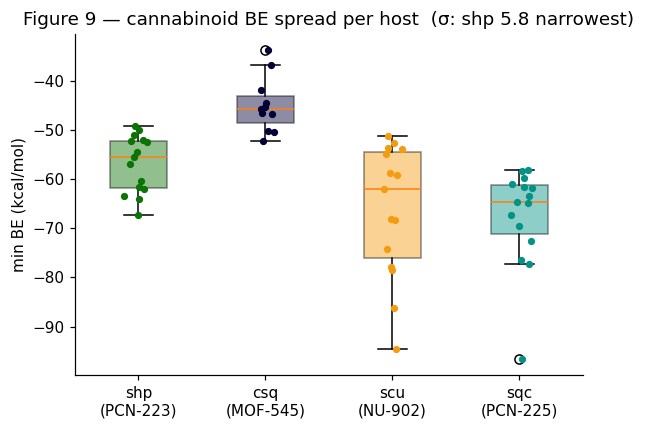

In [13]:
# Figure 9 — cannabinoid BE spread per host (csq sampling-biased).
fig, ax = plt.subplots(figsize=(5.5, 4))
data = [be_table.loc[cb, t].dropna().values for t in TOPOLOGIES]
bp = ax.boxplot(data, tick_labels=[TOPO_LABEL[t] for t in TOPOLOGIES], patch_artist=True)
rng = np.random.default_rng(0)
for patch, t in zip(bp["boxes"], TOPOLOGIES):
    patch.set_facecolor(TOPO_COLOR[t]); patch.set_alpha(0.45)
for i, t in enumerate(TOPOLOGIES, 1):
    yv = be_table.loc[cb, t].dropna()
    ax.scatter(rng.normal(i, 0.05, len(yv)), yv, s=14, color=TOPO_COLOR[t], zorder=3)
ax.set_ylabel("min BE (kcal/mol)")
ax.set_title("Figure 9 — cannabinoid BE spread per host  (σ: shp 5.8 narrowest)")
print("cannabinoid std per host:", {t: round(be_table.loc[cb, t].std(), 1) for t in TOPOLOGIES})
fig.tight_layout(); fig.savefig(FIG / "cannabinoid_spread_boxplot.png", dpi=150, bbox_inches="tight"); plt.show()

Table 11 — CBD-referenced relative binding energy:


,shp,csq,scu,sqc
guest,,,,
CBC,2.10,4.63,5.01,-1.89
CBCA,-15.19,NaN,-15.52,-3.37
CBDA,-9.44,NaN,-27.35,-15.01
CBDV,2.87,-5.67,3.80,-3.05
CBDVA,-8.37,NaN,-9.38,-15.71
CBG,-0.26,12.80,-19.05,-0.30
CBGA,-9.96,-0.26,-35.79,-11.13
CBL,-3.38,1.06,6.10,3.47
CBLA,-4.88,-3.86,-9.49,-35.12


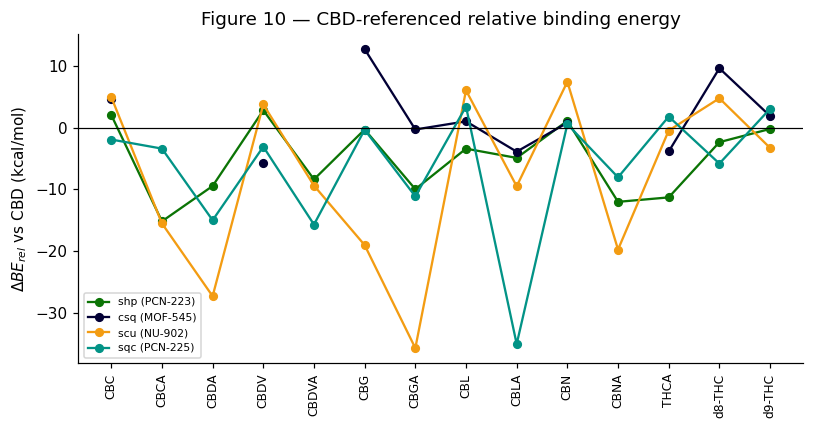

In [14]:
# Table 11 + Figure 10 — CBD-referenced relative binding energy.
print("Table 11 — CBD-referenced relative binding energy:"); display(diff.round(2))
fig, ax = plt.subplots(figsize=(7.5, 4))
for t in TOPOLOGIES:
    ax.plot(diff.index, diff[t], "o-", ms=5, color=TOPO_COLOR[t], label=f"{t} ({FRAMEWORKS[t]})")
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel(r"$\Delta BE_{rel}$ vs CBD (kcal/mol)")
ax.set_title("Figure 10 — CBD-referenced relative binding energy")
ax.tick_params(axis="x", rotation=90, labelsize=8); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "diffBE_CBD_relative_full.png", dpi=150, bbox_inches="tight"); plt.show()

## Interactive explorer

A self-contained interactive dashboard built from the same committed tables, saved
to [`thesis/070_CORRELATION/selectivity_explorer.html`](../thesis/070_CORRELATION/selectivity_explorer.html):
a binding-energy heatmap, a descriptor explorer (every 2D and 3D descriptor), and the
csq wall-contact trend. The descriptor-explorer figure also renders inline.

In [15]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

minBE = be_table.min(axis=1)
desc_all = pd.concat([g2[["MolWt", "NumRotatableBonds", "NumHDonors", "NumHAcceptors", "NumAromaticRings", "MolLogP", "TPSA"]],
                      d3[["Rg", "NPR1", "NPR2", "min_rot_width", "long_axis_extent"]]], axis=1)
EXPLORE = [c for c in ["Rg", "min_rot_width", "MolWt", "MolLogP", "TPSA", "NumHAcceptors",
                       "NumHDonors", "NumRotatableBonds", "NPR1"] if c in desc_all.columns]

fig_ex = go.Figure()
for fam, col in FAM_COLOR.items():
    abbrs = ph if fam == "Pharmaceutical" else cb
    fig_ex.add_scatter(x=desc_all.loc[abbrs, EXPLORE[0]], y=minBE.reindex(abbrs), text=list(abbrs),
                       mode="markers+text", textposition="top center", textfont=dict(size=8), name=fam,
                       marker=dict(size=11, color=col, line=dict(width=0.5, color="white")),
                       hovertemplate="%{text}<br>%{x:.2f}<br>BE %{y:.1f} kcal/mol<extra></extra>")
fig_ex.update_layout(title="Descriptor explorer — strongest min BE vs guest descriptor",
                     xaxis_title=EXPLORE[0], yaxis_title="min BE (kcal/mol)", height=520,
                     updatemenus=[dict(buttons=[dict(method="update", label=d,
                         args=[{"x": [desc_all.loc[ph, d], desc_all.loc[cb, d]]}, {"xaxis": {"title": d}}]) for d in EXPLORE],
                         x=1.0, xanchor="right", y=1.15, direction="down")])

fig_hm = go.Figure(go.Heatmap(z=be_table.loc[ph + cb, TOPOLOGIES].to_numpy(),
    x=[TOPO_LABEL[t].replace("\n", " ") for t in TOPOLOGIES], y=ph + cb, colorscale="Viridis_r",
    colorbar=dict(title="min BE"), hovertemplate="%{y} · %{x}<br>%{z:.1f} kcal/mol<extra></extra>"))
fig_hm.update_layout(title="Minimum binding energy", height=760, yaxis=dict(autorange="reversed"))

s = samp.dropna(subset=["Rg", "pct_within_7A"])
fig_wc = go.Figure(go.Scatter(x=s.Rg, y=s.pct_within_7A, text=s.abbrev, mode="markers",
    marker=dict(size=11, color=HOST_COLORS["MOF-545"]), hovertemplate="%{text}<br>Rg %{x:.2f}<br>%{y:.2f}%<extra></extra>"))
fig_wc.update_layout(title="csq wall-contact access vs Rg", xaxis_title="Rg (Å)",
                     yaxis_title="% SRD configs within 7 Å", height=460)

tabs = [("Binding-energy heatmap", fig_hm), ("Descriptor explorer", fig_ex), ("csq wall contact", fig_wc)]
divs = [pio.to_html(f, full_html=False, include_plotlyjs=False, div_id=f"fig{i}") for i, (_, f) in enumerate(tabs)]
btns = "".join(f'<button onclick="show({i})">{n}</button>' for i, (n, _) in enumerate(tabs))
panels = "".join(f'<div class="panel" style="display:{"block" if i==0 else "none"}">{d}</div>' for i, d in enumerate(divs))
html = f'''<!doctype html><html><head><meta charset="utf-8"><title>Topology-selectivity explorer</title>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>body{{font-family:sans-serif;max-width:900px;margin:18px auto;color:#222}}
button{{padding:8px 14px;border:none;background:none;cursor:pointer;font-size:13px;color:#888;border-bottom:2px solid transparent}}
button.active{{color:#111;border-bottom:2px solid #222;font-weight:500}}</style></head>
<body><h2 style="font-weight:500">Topology-selectivity explorer</h2>
<p style="color:#666;font-size:13px">Generated from the committed tables by <code>selectivity-analysis.ipynb</code>. Hover for values; use the dropdown in the Descriptor explorer tab.</p>
<div style="border-bottom:1px solid #ddd;margin-bottom:14px">{btns}</div>{panels}
<script>function show(n){{document.querySelectorAll('.panel').forEach((p,i)=>p.style.display=i===n?'block':'none');
document.querySelectorAll('button').forEach((b,i)=>b.className=i===n?'active':'');window.dispatchEvent(new Event('resize'));}}show(0);</script>
</body></html>'''
(CORR / "selectivity_explorer.html").write_text(html, encoding="utf-8")
print("Wrote", CORR / "selectivity_explorer.html")
fig_ex

Wrote ../thesis/070_CORRELATION/selectivity_explorer.html


---
These figures and tables are interpreted in
[`results/selectivity-assessments-results.md`](../results/selectivity-assessments-results.md);
the method-reliability diagnostics are in
[`results/method-assessments.md`](../results/method-assessments.md).